# 02 — LLM-as-Policy: Dual-Agent Zero-Shot Battery Control

**Phase 1 / Month 2** · MSc Thesis — ECLIPSE project
Supervisor: Dr. Panagiotis Kasnesis | Student: Antonios Bastoulis

---

This notebook evaluates frontier LLMs as zero-shot battery controllers in a **two-agent setup**
that mirrors the Phase 4 multi-agent deployment:

| Agent | Buildings | Observability |
|-------|-----------|---------------|
| **α** | B0, B1, B2 | Sees only its own 3 buildings |
| **β** | B3, B4, B5 | Sees only its own 3 buildings |

Each timestep makes **2 independent API calls** (one per agent). The district reward is the
sum across all 6 buildings. Neither agent knows what the other is doing — this is the
Action-Only coordination baseline.

**All logic is defined inline** — no `src/agent` dependency — so bins, state rendering,
prompt, and the `APIProvider` class are identical to `03_slm_colab` and results are directly comparable.

**Rollout window:** 300 hourly steps starting at `t=3624` (matches `03_slm_colab` for direct comparison).

**Providers tested:**

| Provider | Model | API quirks |
|----------|-------|------------|
| Anthropic | `claude-haiku-4-5` | Native client; standard `max_tokens`, `temperature=0`. |
| DeepSeek | `deepseek-chat` (V3) | OpenAI-compat; standard `max_tokens`, `temperature=0`. |
| Kimi | `kimi-k2.5` | OpenAI-compat (Moonshot endpoint); **requires `temperature=1`**. |
| OpenAI | `gpt-5.4-nano` | Native OpenAI; reasoning-family — uses **`max_completion_tokens`** (not `max_tokens`) and **only supports `temperature=1`**, so we omit the temperature override. |

These per-model quirks are auto-detected inside `APIProvider.complete()` based on
the `model` string and an optional `temperature` field in `PROVIDERS`.

**API keys:** loaded from `.env` at project root.
Required vars: `ANTHROPIC_API_KEY`, `DEEPSEEK_API_KEY`, `KIMI_API_KEY`, `OPENAI_API_KEY`.


## § 0 — Config
> **Change experiment parameters here only.** Nothing else needs editing.

In [1]:
import sys
from pathlib import Path

# ── Make src/ importable ──────────────────────────────────────────────────
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from dotenv import load_dotenv
load_dotenv(PROJECT_ROOT / ".env")

# ── Provider list ─────────────────────────────────────────────────────────
# Comment / uncomment entries to control which providers run.
PROVIDERS: list[dict] = [
    {
        "name":     "anthropic",
        "model":    "claude-haiku-4-5",
        "key_env":  "ANTHROPIC_API_KEY",
        "base_url": None,
    },
    {
        "name":     "deepseek",
        "model":    "deepseek-chat",
        "key_env":  "DEEPSEEK_API_KEY",
        "base_url": "https://api.deepseek.com/v1",
    },
    {
        "name":     "kimi",
        "model":    "kimi-k2.5",
        "key_env":  "KIMI_API_KEY",
        "base_url": "https://api.moonshot.ai/v1",
        "temperature": 1.0,
    },
    {
        "name":     "openai",
        "model":    "gpt-5.4-nano",
        "key_env":  "OPENAI_API_KEY",
        "base_url": None,
    },
]

# ── Dual-agent split ─────────────────────────────────────────────────────
AGENT_A_BUILDINGS: list[int] = [0, 1, 2]
AGENT_B_BUILDINGS: list[int] = [3, 4, 5]

# ── Timeout ──────────────────────────────────────────────────────────────
LLM_TIMEOUT_S: float = 45.0

# ── Experiment window (matches 03_slm_colab for direct comparison) ───────
WEEK_START: int = 3624
WEEK_LEN:   int = 300

# ── Output ───────────────────────────────────────────────────────────────
ARTIFACTS = Path("artifacts").resolve()
ARTIFACTS.mkdir(exist_ok=True)

# ── Sanity print ─────────────────────────────────────────────────────────
import os
print(f"Project root   : {PROJECT_ROOT}")
print(f"Window         : t{WEEK_START}..{WEEK_START + WEEK_LEN - 1} ({WEEK_LEN} steps)")
print(f"Agent α        : buildings {AGENT_A_BUILDINGS}")
print(f"Agent β        : buildings {AGENT_B_BUILDINGS}")
print(f"Timeout/call   : {LLM_TIMEOUT_S}s")
print(f"\nProviders ({len(PROVIDERS)}):")
for p in PROVIDERS:
    has_key = bool(os.environ.get(p["key_env"], "").strip())
    flag = "✓" if has_key else "✗ MISSING"
    print(f"  [{flag}] {p['name']:10s} model={p['model']:35s} env={p['key_env']}")

ModuleNotFoundError: No module named 'dotenv'

## § 1 — Imports

In [ ]:
import concurrent.futures
import json
import logging
import random
import re
import time
import warnings

import citylearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from citylearn.citylearn import CityLearnEnv

from src.env import SEED, BUILDINGS, make_env, snapshot_state

warnings.filterwarnings("ignore")
np.random.seed(SEED)
random.seed(SEED)

print(f"CityLearn {citylearn.__version__}")
print("src.env loaded.")

CityLearn 2.5.0
src.env loaded.


## § 1b — Agent Utilities

All domain logic is defined inline here — identical to `03_slm_colab` so both notebooks
produce directly comparable state representations and results.

Contains: thresholds, bucket functions, `render_state`, `parse_actions`,
`make_minimal_prompt`, `APIProvider`, `make_policy_llm`.

In [3]:
import os

_logger = logging.getLogger("api_provider")

# ── Thresholds (identical to 03_slm_colab) ─────────────────────────────────
PRICE_PEAK_THRESHOLD      = 0.30   # $/kWh — above this = PEAK price
IRRADIANCE_LOW_THRESHOLD  = 50     # W/m²  — below this = NONE
IRRADIANCE_HIGH_THRESHOLD = 600    # W/m²  — above this = HIGH


def price_bucket(v):
    if v is None: return "?"
    return "PEAK" if v >= PRICE_PEAK_THRESHOLD else "LOW"

def carbon_bucket(v):
    if v is None: return "?"
    if v < 0.12: return "LOW"
    if v < 0.25: return "MID"
    return "HIGH"

def solar_bucket(v):
    if v is None: return "?"
    if v <= 0.0: return "NONE"
    if v < 0.5: return "LOW"
    return "HIGH"

def irradiance_bucket(v):
    if v is None: return "?"
    if v < IRRADIANCE_LOW_THRESHOLD: return "NONE"
    if v < IRRADIANCE_HIGH_THRESHOLD: return "LOW"
    return "HIGH"


# ── State renderer (verbatim from 03_slm_colab) ────────────────────────────
def render_state(snap):
    """Convert a snapshot (list of building dicts) into an LLM prompt string."""
    if not snap:
        return "(empty snapshot)"
    d0   = snap[0]
    hour = int(d0.get("hour", 1)) - 1
    day  = int(d0.get("day_type", 1)) - 1
    day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

    prc = d0.get("electricity_pricing", None)
    crb = d0.get("carbon_intensity", None)

    header = (
        f"Month {d0.get('month', '?')}, {day_names[day]} {hour:02d}:00  |  "
        f"price={prc:.3f} ({price_bucket(prc)})  |  "
        f"carbon={crb:.3f} ({carbon_bucket(crb)})"
    )

    fp1 = d0.get("electricity_pricing_predicted_1", None)
    fp2 = d0.get("electricity_pricing_predicted_2", None)
    fi1 = d0.get("solar_irradiance_predicted_1", None)
    forecast = (
        f"Forecast:  price+6h={price_bucket(fp1)}  "
        f"price+12h={price_bucket(fp2)}  "
        f"solar+6h={irradiance_bucket(fi1)}"
    )

    lines = [header, forecast, "Buildings:"]
    for i, d in enumerate(snap):
        soc  = d.get("electrical_storage_soc", 0.0)
        sol  = d.get("solar_generation", 0.0)
        load = d.get("non_shiftable_load", 0.0)
        net  = d.get("net_electricity_consumption_last", 0.0)
        lines.append(
            f"  B{i}: SoC={soc*100:5.1f}%  "
            f"load={load:.2f} kWh  "
            f"last_net={net:+.2f} kWh  "
            f"solar={solar_bucket(sol)}"
        )
    return "\n".join(lines)


# ── Action parser — discrete CHARGE/DISCHARGE/IDLE bins (verbatim from 03) ─
_ACTION_RE = re.compile(
    r"<action\s+building\s*=\s*(\d+)\s*>\s*(CHARGE|DISCHARGE|IDLE)_?(\d+)?\s*</action>",
    re.IGNORECASE,
)

def parse_actions(text, n_buildings):
    """Extract per-building discrete actions and map to float values."""
    acts = [0.0] * n_buildings
    for m in _ACTION_RE.finditer(text):
        idx       = int(m.group(1))
        direction = m.group(2).upper()
        amt_str   = m.group(3)

        val = 0.0
        if direction == "CHARGE" and amt_str:
            val = float(amt_str) / 100.0
        elif direction == "DISCHARGE" and amt_str:
            val = -float(amt_str) / 100.0
        elif direction == "IDLE":
            val = 0.0

        if 0 <= idx < n_buildings:
            acts[idx] = float(np.clip(val, -1.0, 1.0))
    return acts


# ── Prompt (verbatim from 03_slm_colab make_minimal_prompt) ────────────────
def make_minimal_prompt(n_buildings: int = 6) -> str:
    """Prompt with variable semantics, indirect instructions, and Chain-of-Thought reasoning."""
    action_fmt = "\n".join(
        f"<action building={i}>YOUR_CHOICE</action>" for i in range(n_buildings)
    )
    return f"""\
You are an energy management agent for {n_buildings} buildings. Goal: minimize grid dependency and energy costs over time.

[Actions] — choose exactly one per building:
CHARGE_100, CHARGE_80, CHARGE_60, CHARGE_40, CHARGE_20, IDLE, DISCHARGE_20, DISCHARGE_40, DISCHARGE_60, DISCHARGE_80, DISCHARGE_100

[State Variables & Environment]
- 'price': Current cost of grid electricity. PEAK indicates high cost.
- 'solar': Renewable energy generated locally.
- 'load': Energy demanded by the building's operations. High load means the building needs a lot of power.
- 'SoC': Battery State of Charge (0% = empty, 100% = full).
- Charging stores energy. Doing so when solar is HIGH or price is LOW is efficient, but charging from the grid increases district demand.
- Discharging uses stored energy to serve the 'load', directly reducing grid dependency. This is highly beneficial when 'price' is PEAK or 'load' is high and SoC is sufficient.
- Forecast fields show anticipated conditions 6 or 12 hours ahead, helping you plan when to store or release energy.
-Avoid aggresive actions, prefer CHARGE_20,CHARGE_40,DISCHARGE_20 OR DISCHARGE_40.
-Never charge when SOC is higher than 90% and never discharge when SOC is lower than 10%.

[Reasoning]
Before choosing actions, briefly analyze the state in a <thought> block.
CRITICAL: Keep your thought extremely brief (UNDER 15 WORDS) to save computation time.

[Output Format]
<thought>
Ultra-short analysis here...
</thought>
{action_fmt}
"""


# ── API Provider ───────────────────────────────────────────────────────────
# Per-model API quirks handled here so the rest of the notebook stays clean:
#   * OpenAI reasoning / GPT-5 family (gpt-5*, o1*, o3*, o4*) only supports
#     `max_completion_tokens` (not `max_tokens`) and `temperature=1` (default,
#     so we just omit the override).
#   * Kimi `kimi-k2.5` requires `temperature=1` (set via PROVIDERS spec).
#   * Anthropic and DeepSeek follow the standard convention (max_tokens,
#     temperature=0 for determinism).

# Models that use the OpenAI "reasoning" parameter conventions
_OPENAI_REASONING_PREFIXES = ("gpt-5", "o1", "o3", "o4")


def _is_openai_reasoning_model(model: str) -> bool:
    m = model.lower()
    return any(m.startswith(p) for p in _OPENAI_REASONING_PREFIXES)


class APIProvider:
    """Drop-in for LocalHFProvider — same .complete()/.step() interface.

    Wraps Anthropic (native client) and any OpenAI-compatible endpoint
    (DeepSeek, Kimi, OpenAI). Timeout is enforced via a background thread
    so a hung API call never freezes the rollout.

    Args:
        name:        Friendly name used in logs / result labels.
        model:       Model ID (e.g. 'claude-haiku-4-5', 'gpt-5.4-nano').
        key_env:     Name of the env var holding the API key.
        base_url:    Override endpoint for OpenAI-compat providers.
        temperature: Force a specific sampling temperature. If None we pick:
                     0.0 for deterministic providers, and skip the override
                     entirely for OpenAI reasoning models (they only allow 1).
    """

    def __init__(
        self,
        name: str,
        model: str,
        key_env: str,
        base_url: str | None = None,
        temperature: float | None = None,
    ):
        self.name        = name
        self.model       = model
        self.label       = f"{name}:{model}"
        self.temperature = temperature

        api_key = os.environ.get(key_env, "").strip()
        if not api_key:
            raise RuntimeError(f"Missing API key — set env var {key_env!r}")

        if name == "anthropic":
            try:
                from anthropic import Anthropic
            except ImportError as e:
                raise ImportError("pip install anthropic") from e
            self.client = Anthropic(api_key=api_key)
            self._kind  = "anthropic"
        else:
            try:
                from openai import OpenAI
            except ImportError as e:
                raise ImportError("pip install openai") from e
            self.client = OpenAI(api_key=api_key, base_url=base_url)
            self._kind  = "openai_compat"

        # Decide once whether this is the OpenAI reasoning / GPT-5 family.
        # Only relevant for native OpenAI calls — third-party OpenAI-compat
        # endpoints (DeepSeek, Kimi) keep the classic max_tokens convention.
        self._is_openai_reasoning = (
            name == "openai" and _is_openai_reasoning_model(model)
        )

    def complete(
        self,
        system: str,
        user: str,
        max_tokens: int = 512,
        timeout_s: float | None = 45.0,
        **kwargs,
    ) -> str:
        """Call the API and return assistant text only."""

        def _call() -> str:
            if self._kind == "anthropic":
                temp = 0.0 if self.temperature is None else self.temperature
                resp = self.client.messages.create(
                    model=self.model,
                    system=system,
                    messages=[{"role": "user", "content": user}],
                    max_tokens=max_tokens,
                    temperature=temp,
                )
                return "".join(
                    b.text for b in resp.content if getattr(b, "type", None) == "text"
                )

            # OpenAI / OpenAI-compatible (DeepSeek, Kimi, OpenAI native)
            kw: dict = dict(
                model=self.model,
                messages=[
                    {"role": "system", "content": system},
                    {"role": "user",   "content": user},
                ],
            )

            if self._is_openai_reasoning:
                # GPT-5 / o-series: max_completion_tokens, temperature must be
                # default (1) — pass nothing rather than override.
                kw["max_completion_tokens"] = max_tokens
            else:
                kw["max_tokens"] = max_tokens
                # Default to 0 for determinism unless the spec forces a value
                # (e.g. Kimi requires temperature=1).
                kw["temperature"] = 0.0 if self.temperature is None else self.temperature

            resp = self.client.chat.completions.create(**kw)
            return resp.choices[0].message.content

        if timeout_s is None:
            return _call()

        # Use a background thread so a hung call never blocks the rollout.
        executor = concurrent.futures.ThreadPoolExecutor(
            max_workers=1, thread_name_prefix="api_call"
        )
        future = executor.submit(_call)
        try:
            result = future.result(timeout=timeout_s)
            executor.shutdown(wait=False)
            return result
        except concurrent.futures.TimeoutError:
            future.cancel()
            executor.shutdown(wait=False)
            raise TimeoutError(f"{self.label} did not respond within {timeout_s:.0f}s")
        except Exception:
            executor.shutdown(wait=False)
            raise

    def step(
        self,
        state_text: str,
        system: str | None = None,
        n_buildings: int = 6,
        max_retries: int = 2,
        timeout_s: float = 45.0,
        max_tokens: int = 250,
        **kwargs,
    ) -> tuple[list[float], str, bool]:
        """Query the API for one environment step.

        Returns (actions, raw_response, used_fallback).
        On timeout the step returns fallback zeros immediately without retrying.
        """
        _system  = system or make_minimal_prompt(n_buildings)
        last_raw = ""

        for attempt in range(max_retries):
            try:
                last_raw = self.complete(
                    _system,
                    f"STATE:\n{state_text}",
                    max_tokens=max_tokens,
                    timeout_s=timeout_s,
                )
                if _ACTION_RE.search(last_raw):
                    return parse_actions(last_raw, n_buildings), last_raw, False
                _logger.debug("No action tags (attempt %d): %s", attempt + 1, last_raw[:80])
            except TimeoutError as exc:
                last_raw = f"TIMEOUT: {exc}"
                _logger.warning("API timeout provider=%s", self.name)
                break
            except Exception as exc:
                last_raw = f"ERROR (attempt {attempt + 1}): {exc}"
                if attempt < max_retries - 1:
                    time.sleep(1.0)

        _logger.warning("API fallback provider=%s — returning zeros", self.name)
        return [0.0] * n_buildings, last_raw, True


# ── Policy wrapper (verbose format identical to 03_slm_colab) ──────────────
def make_policy_llm(
    provider: "APIProvider",
    n_buildings: int = 6,
    agent_label: str = "",
    system: str | None = None,
    verbose: bool = True,
    **step_kwargs,
):
    """Bind an APIProvider into a rollout-compatible policy function.

    Verbose print format (one line per call):
      t=  5 [α] B0:42%→+0.40  B1:61%→+0.00  B2:28%→-0.80  | '<action ...'
    """
    _system = system or make_minimal_prompt(n_buildings)
    _label  = f"[{agent_label}] " if agent_label else ""

    def policy(snap: list[dict], t: int):
        state_text = render_state(snap)
        acts, raw, fallback = provider.step(
            state_text,
            system=_system,
            n_buildings=n_buildings,
            **step_kwargs,
        )
        if verbose:
            fb_tag   = " [FALLBACK]" if fallback else ""
            bldg_str = "  ".join(
                f"B{i}:{snap[i]['electrical_storage_soc']*100:.0f}%→{acts[i]:+.2f}"
                for i in range(len(acts))
            )
            print(
                f"  t={t:3d} {_label}{bldg_str}"
                f"  |  {raw.replace(chr(10), ' ')[:55].strip()!r}{fb_tag}"
            )
        return acts, raw, fallback

    return policy


print("APIProvider, render_state, parse_actions, make_minimal_prompt, make_policy_llm — all defined.")
print("Discrete action bins: CHARGE_100..20, IDLE, DISCHARGE_20..100 (matches 03_slm_colab).")
print("API quirks: OpenAI gpt-5/o-series → max_completion_tokens + default temperature;")
print("            Kimi k2.5 → temperature=1 (set in PROVIDERS); others → max_tokens + temp=0.")
print(f"\n--- make_minimal_prompt(3) ---")
print(make_minimal_prompt(3))


APIProvider, render_state, parse_actions, make_minimal_prompt, make_policy_llm — all defined.
Discrete action bins: CHARGE_100..20, IDLE, DISCHARGE_20..100 (matches 03_slm_colab).
API quirks: OpenAI gpt-5/o-series → max_completion_tokens + default temperature;
            Kimi k2.5 → temperature=1 (set in PROVIDERS); others → max_tokens + temp=0.

--- make_minimal_prompt(3) ---
You are an energy management agent for 3 buildings. Goal: minimize grid dependency and energy costs over time.

[Actions] — choose exactly one per building:
CHARGE_100, CHARGE_80, CHARGE_60, CHARGE_40, CHARGE_20, IDLE, DISCHARGE_20, DISCHARGE_40, DISCHARGE_60, DISCHARGE_80, DISCHARGE_100

[State Variables & Environment]
- 'price': Current cost of grid electricity. PEAK indicates high cost.
- 'solar': Renewable energy generated locally.
- 'load': Energy demanded by the building's operations. High load means the building needs a lot of power.
- 'SoC': Battery State of Charge (0% = empty, 100% = full).
- Charging s

## § 2 — Environment

In [4]:
_env = make_env(
    start=WEEK_START,
    end=WEEK_START + WEEK_LEN - 1,
    obs_set="llm",
    reward_fn="merlin",
)
_obs, _ = _env.reset()
print(f"buildings      : {len(_obs)}")
print(f"obs / building : {len(_obs[0])}  (llm obs set — 9 real-time vars in the obs vector)")
print(f"steps / episode: {_env.time_steps}")
print(f"reward fn      : {type(_env.reward_function).__name__}")

_snap = snapshot_state(_env)
_FORECAST_KEYS = [
    "electricity_pricing_predicted_1",
    "electricity_pricing_predicted_2",
    "solar_irradiance_predicted_1",
]

print(f"\nsnapshot_state() returns {len(_snap[0])} fields per building:")
print(f"  9 real-time : month, day_type, hour, electricity_pricing, carbon_intensity,")
print(f"                solar_generation, non_shiftable_load, electrical_storage_soc,")
print(f"                net_electricity_consumption_last")
print(f"  3 forecasts : electricity_pricing_predicted_1  (price  +6 h, $/kWh)")
print(f"                electricity_pricing_predicted_2  (price +12 h, $/kWh)")
print(f"                solar_irradiance_predicted_1     (irradiance +6 h, W/m²)")

print(f"\nForecast availability at t=0 (None → column missing in dataset):")
d0 = _snap[0]
for k in _FORECAST_KEYS:
    print(f"  {k}: {d0[k]}")

print(f"\nBuilding states at t=0:")
for i, d in enumerate(_snap):
    print(
        f"  B{i}: SoC={d['electrical_storage_soc']*100:.1f}%  "
        f"load={d['non_shiftable_load']:.2f}  "
        f"price={d['electricity_pricing']:.3f}  "
        f"price+6h={d['electricity_pricing_predicted_1']}  "
        f"irr+6h={d['solar_irradiance_predicted_1']}"
    )

buildings      : 6
obs / building : 9  (llm obs set — 9 real-time vars in the obs vector)
steps / episode: 300
reward fn      : MERLINReward

snapshot_state() returns 12 fields per building:
  9 real-time : month, day_type, hour, electricity_pricing, carbon_intensity,
                solar_generation, non_shiftable_load, electrical_storage_soc,
                net_electricity_consumption_last
  3 forecasts : electricity_pricing_predicted_1  (price  +6 h, $/kWh)
                electricity_pricing_predicted_2  (price +12 h, $/kWh)
                solar_irradiance_predicted_1     (irradiance +6 h, W/m²)

Forecast availability at t=0 (None → column missing in dataset):
  electricity_pricing_predicted_1: 0.20999999344348907
  electricity_pricing_predicted_2: 0.20999999344348907
  solar_irradiance_predicted_1: 125.0

Building states at t=0:
  B0: SoC=0.0%  load=0.60  price=0.210  price+6h=0.20999999344348907  irr+6h=125.0
  B1: SoC=0.0%  load=1.68  price=0.210  price+6h=0.20999999344348907 

## § 3 — State Renderer

`snapshot_state()` returns **12 fields** per building: 9 real-time signals + 3 short-horizon
forecasts (price +6 h, price +12 h, solar irradiance +6 h W/m²).

`render_state()` converts these into a human-readable prompt string, inserting a **Forecast**
line between the district header and the per-building table, e.g.:

```
Month 12, Wed 08:00  |  price=0.210 (LOW)  |  carbon=0.202 (PEAK)
Forecast:  price+6h=PEAK  price+12h=LOW  solar+6h=HIGH
Buildings:
  B0: SoC= 45.3%  load=1.20 kWh  last_net=+0.85 kWh  solar=LOW
  ...
```

Each agent receives only its **own 3 buildings**. `render_state()` re-labels from B0
regardless of the slice, so both agents see identically structured prompts.

In [5]:
snap_a = _snap[0:3]   # Agent α view
snap_b = _snap[3:6]   # Agent β view

print("=" * 60)
print("Agent α state (buildings 0-2):")
print("=" * 60)
print(render_state(snap_a))

print()
print("=" * 60)
print("Agent β state (buildings 3-5):")
print("=" * 60)
print(render_state(snap_b))

Agent α state (buildings 0-2):
Month 12, Thu 23:00  |  price=0.210 (LOW)  |  carbon=0.202 (MID)
Forecast:  price+6h=LOW  price+12h=LOW  solar+6h=LOW
Buildings:
  B0: SoC=  0.0%  load=0.60 kWh  last_net=+0.00 kWh  solar=NONE
  B1: SoC=  0.0%  load=1.68 kWh  last_net=+0.00 kWh  solar=NONE
  B2: SoC=  0.0%  load=0.28 kWh  last_net=+0.00 kWh  solar=NONE

Agent β state (buildings 3-5):
Month 12, Thu 23:00  |  price=0.210 (LOW)  |  carbon=0.202 (MID)
Forecast:  price+6h=LOW  price+12h=LOW  solar+6h=LOW
Buildings:
  B0: SoC=  0.0%  load=0.45 kWh  last_net=+0.00 kWh  solar=NONE
  B1: SoC=  0.0%  load=1.03 kWh  last_net=+0.00 kWh  solar=NONE
  B2: SoC=  0.0%  load=1.59 kWh  last_net=+0.00 kWh  solar=NONE


## § 4 — Prompt Preview

`make_minimal_prompt(3)` is the active prompt — it is printed by the § 1b utilities cell
above and used automatically by every provider cell below.

In [6]:
# Show the 3-building prompt that both agents will use
print(make_minimal_prompt(3))

You are an energy management agent for 3 buildings. Goal: minimize grid dependency and energy costs over time.

[Actions] — choose exactly one per building:
CHARGE_100, CHARGE_80, CHARGE_60, CHARGE_40, CHARGE_20, IDLE, DISCHARGE_20, DISCHARGE_40, DISCHARGE_60, DISCHARGE_80, DISCHARGE_100

[State Variables & Environment]
- 'price': Current cost of grid electricity. PEAK indicates high cost.
- 'solar': Renewable energy generated locally.
- 'load': Energy demanded by the building's operations. High load means the building needs a lot of power.
- 'SoC': Battery State of Charge (0% = empty, 100% = full).
- Charging stores energy. Doing so when solar is HIGH or price is LOW is efficient, but charging from the grid increases district demand.
- Discharging uses stored energy to serve the 'load', directly reducing grid dependency. This is highly beneficial when 'price' is PEAK or 'load' is high and SoC is sufficient.
- Forecast fields show anticipated conditions 6 or 12 hours ahead, helping you

## § 5 — Provider Setup & Smoke Test

`PROVIDER_OBJS` is initialised in the first cell. Each subsequent cell smoke-tests
**one provider independently** — you can interrupt a hung cell without losing others.

Providers that fail (timeout, missing key, import error) are excluded from `PROVIDER_OBJS`
and automatically skipped by every rollout cell in §§ 9–12.

In [7]:
PROVIDER_OBJS: dict[str, APIProvider] = {}
print("PROVIDER_OBJS initialised — run per-provider smoke-test cells below.")
print(f"Providers configured in § 0: {[p['name'] for p in PROVIDERS]}")

PROVIDER_OBJS initialised — run per-provider smoke-test cells below.
Providers configured in § 0: ['anthropic', 'deepseek', 'kimi', 'openai']


In [8]:
# ── Smoke test: Anthropic ─────────────────────────────────────────────────
_spec = next((s for s in PROVIDERS if s["name"] == "anthropic"), None)
if _spec is None:
    print("[anthropic] not in PROVIDERS list — skipped")
else:
    try:
        _p   = APIProvider(**_spec)
        _out = _p.complete("You answer in one word.", "Say PONG.", timeout_s=20.0)
        PROVIDER_OBJS["anthropic"] = _p
        print(f"  [✓] {_p.label:45s} → {_out.strip()[:40]!r}")
    except Exception as _exc:
        print(f"  [✗] anthropic  {_spec['model']:35s} skipped: {_exc}")
print(f"Active providers: {list(PROVIDER_OBJS.keys())}")

INFO:httpx:HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


  [✓] anthropic:claude-haiku-4-5                    → 'PONG'
Active providers: ['anthropic']


In [9]:
# ── Smoke test: DeepSeek ─────────────────────────────────────────────────
_spec = next((s for s in PROVIDERS if s["name"] == "deepseek"), None)
if _spec is None:
    print("[deepseek] not in PROVIDERS list — skipped")
else:
    try:
        _p   = APIProvider(**_spec)
        _out = _p.complete("You answer in one word.", "Say PONG.", timeout_s=20.0)
        PROVIDER_OBJS["deepseek"] = _p
        print(f"  [✓] {_p.label:45s} → {_out.strip()[:40]!r}")
    except Exception as _exc:
        print(f"  [✗] deepseek   {_spec['model']:35s} skipped: {_exc}")
print(f"Active providers: {list(PROVIDER_OBJS.keys())}")

INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"


  [✓] deepseek:deepseek-chat                        → 'PONG'
Active providers: ['anthropic', 'deepseek']


In [10]:
# ── Smoke test: Kimi / Moonshot ───────────────────────────────────────────
_spec = next((s for s in PROVIDERS if s["name"] == "kimi"), None)
if _spec is None:
    print("[kimi] not in PROVIDERS list — skipped")
else:
    try:
        _p   = APIProvider(**_spec)
        _out = _p.complete("You answer in one word.", "Say PONG.", timeout_s=20.0)
        PROVIDER_OBJS["kimi"] = _p
        print(f"  [✓] {_p.label:45s} → {_out.strip()[:40]!r}")
    except Exception as _exc:
        print(f"  [✗] kimi       {_spec['model']:35s} skipped: {_exc}")
print(f"Active providers: {list(PROVIDER_OBJS.keys())}")

INFO:httpx:HTTP Request: POST https://api.moonshot.ai/v1/chat/completions "HTTP/1.1 200 OK"


  [✓] kimi:kimi-k2.5                                → 'PONG'
Active providers: ['anthropic', 'deepseek', 'kimi']


In [11]:
# ── Smoke test: OpenAI ────────────────────────────────────────────────────
_spec = next((s for s in PROVIDERS if s["name"] == "openai"), None)
if _spec is None:
    print("[openai] not in PROVIDERS list — skipped")
else:
    try:
        _p   = APIProvider(**_spec)
        _out = _p.complete("You answer in one word.", "Say PONG.", timeout_s=20.0)
        PROVIDER_OBJS["openai"] = _p
        print(f"  [✓] {_p.label:45s} → {_out.strip()[:40]!r}")
    except Exception as _exc:
        print(f"  [✗] openai     {_spec['model']:35s} skipped: {_exc}")
print(f"Active providers: {list(PROVIDER_OBJS.keys())}")

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


  [✓] openai:gpt-5.4-nano                           → 'PONG'
Active providers: ['anthropic', 'deepseek', 'kimi', 'openai']


## § 6 — Rollout Functions

In [12]:
def run_policy(
    name: str,
    policy_fn,
    start: int = WEEK_START,
    length: int = WEEK_LEN,
    reward_fn: str = "merlin",
) -> tuple[pd.DataFrame, CityLearnEnv, list[dict]]:
    """Single-agent rollout — policy_fn sees all 6 buildings.

    policy_fn signature: (snap, t) -> list[float]  OR  (actions, raw, fallback).
    """
    env = make_env(start=start, end=start + length - 1, obs_set="llm", reward_fn=reward_fn)
    env.reset()

    rows, raw_log = [], []
    done, t, t0 = False, 0, time.time()

    while not done:
        snap   = snapshot_state(env)
        result = policy_fn(snap, t)

        if isinstance(result, tuple):
            acts, raw, fb = result
            raw_log.append({"t": t, "state_text": render_state(snap), "raw": raw, "fallback": bool(fb)})
        else:
            acts = result

        _obs, reward, terminated, truncated, _ = env.step([[float(a)] for a in acts])
        done = bool(terminated or truncated)
        post = snapshot_state(env)

        rows.append({
            "policy": name, "t": t, "price": snap[0]["electricity_pricing"],
            "reward_sum": float(np.sum(reward)),
            **{f"a{i}":   acts[i]                                      for i in range(6)},
            **{f"r{i}":   float(reward[i])                             for i in range(6)},
            **{f"soc{i}": post[i]["electrical_storage_soc"]            for i in range(6)},
            **{f"net{i}": post[i]["net_electricity_consumption_last"]  for i in range(6)},
        })
        t += 1

    df = pd.DataFrame(rows)
    n_fb  = sum(1 for r in raw_log if r["fallback"])
    fb_msg = f" | fallbacks={n_fb}/{len(raw_log)}" if raw_log else ""
    print(f"[{name}] {t} steps in {time.time()-t0:.1f}s | reward={df['reward_sum'].sum():.4f}{fb_msg}")
    return df, env, raw_log

In [13]:
def run_policy_dual_agent(
    name: str,
    policy_a,
    policy_b,
    agent_a_bldgs: list[int] = AGENT_A_BUILDINGS,
    agent_b_bldgs: list[int] = AGENT_B_BUILDINGS,
    start: int = WEEK_START,
    length: int = WEEK_LEN,
    reward_fn: str = "merlin",
    summary_every: int = 24,   # print district summary every N steps (0 = off)
) -> dict:
    """Dual-agent rollout: two LLM calls per step, partial observability.

    Agent α receives snap[agent_a_bldgs], Agent β receives snap[agent_b_bldgs].
    Their actions are combined in global building-index order before env.step().

    Returns dict with keys: df, env, raw_log_a, raw_log_b.
    """
    n_a = len(agent_a_bldgs)
    n_b = len(agent_b_bldgs)
    all_bldgs = agent_a_bldgs + agent_b_bldgs

    env = make_env(start=start, end=start + length - 1, obs_set="llm", reward_fn=reward_fn)
    env.reset()

    rows, raw_log_a, raw_log_b = [], [], []
    done, t, t0 = False, 0, time.time()
    day_reward = 0.0

    while not done:
        snap   = snapshot_state(env)
        snap_a = [snap[i] for i in agent_a_bldgs]
        snap_b = [snap[i] for i in agent_b_bldgs]

        result_a = policy_a(snap_a, t)
        result_b = policy_b(snap_b, t)

        if isinstance(result_a, tuple):
            acts_a, raw_a, fb_a = result_a
            raw_log_a.append({"t": t, "state_text": render_state(snap_a), "raw": raw_a, "fallback": bool(fb_a)})
        else:
            acts_a, fb_a = result_a, False

        if isinstance(result_b, tuple):
            acts_b, raw_b, fb_b = result_b
            raw_log_b.append({"t": t, "state_text": render_state(snap_b), "raw": raw_b, "fallback": bool(fb_b)})
        else:
            acts_b, fb_b = result_b, False

        # Combine α + β into a single 6-action vector in global building order
        acts_combined = [0.0] * (n_a + n_b)
        for local_i, global_i in enumerate(agent_a_bldgs):
            acts_combined[global_i] = acts_a[local_i]
        for local_i, global_i in enumerate(agent_b_bldgs):
            acts_combined[global_i] = acts_b[local_i]

        _obs, reward, terminated, truncated, _ = env.step([[float(a)] for a in acts_combined])
        done = bool(terminated or truncated)
        post = snapshot_state(env)

        step_reward = float(np.sum(reward))
        day_reward += step_reward

        rows.append({
            "policy": name, "t": t, "price": snap[0]["electricity_pricing"],
            "reward_sum": step_reward,
            "reward_a":   float(sum(reward[i] for i in agent_a_bldgs)),
            "reward_b":   float(sum(reward[i] for i in agent_b_bldgs)),
            "fallback_a": fb_a,
            "fallback_b": fb_b,
            **{f"a{i}":   acts_combined[i]                            for i in range(6)},
            **{f"r{i}":   float(reward[i])                            for i in range(6)},
            **{f"soc{i}": post[i]["electrical_storage_soc"]           for i in range(6)},
            **{f"net{i}": post[i]["net_electricity_consumption_last"] for i in range(6)},
        })

        # ── Daily summary line ─────────────────────────────────────────────
        if summary_every > 0 and (t + 1) % summary_every == 0:
            day_num   = (t + 1) // summary_every
            soc_a_str = "/".join(f"{post[i]['electrical_storage_soc']*100:.0f}" for i in agent_a_bldgs)
            soc_b_str = "/".join(f"{post[i]['electrical_storage_soc']*100:.0f}" for i in agent_b_bldgs)
            dist_net  = sum(post[i]["net_electricity_consumption_last"] for i in all_bldgs)
            elapsed   = time.time() - t0
            print(
                f"  ── Day {day_num:2d} | "
                f"SoC α:[{soc_a_str}]%  β:[{soc_b_str}]%  | "
                f"dist_net={dist_net:+.1f} kWh  reward={day_reward:.1f}  | "
                f"{elapsed:.0f}s elapsed"
            )
            day_reward = 0.0

        t += 1

    df     = pd.DataFrame(rows)
    n_fb_a = sum(1 for r in raw_log_a if r["fallback"])
    n_fb_b = sum(1 for r in raw_log_b if r["fallback"])
    print(
        f"[{name}] {t} steps in {time.time()-t0:.1f}s | "
        f"reward={df['reward_sum'].sum():.4f} "
        f"(α={df['reward_a'].sum():.4f}  β={df['reward_b'].sum():.4f}) | "
        f"fallbacks α={n_fb_a} β={n_fb_b}"
    )
    return {"df": df, "env": env, "raw_log_a": raw_log_a, "raw_log_b": raw_log_b}


## § 7 — Reference Policies

In [14]:
def policy_noop(snap: list[dict], t: int) -> list[float]:
    return [0.0] * len(snap)

_rng = np.random.default_rng(SEED)

def policy_random(snap: list[dict], t: int) -> list[float]:
    return _rng.uniform(-1.0, 1.0, size=len(snap)).tolist()

def policy_rbc(snap: list[dict], t: int) -> list[float]:
    """Price + solar aware RBC — uses inline buckets (same as 03_slm_colab)."""
    acts = []
    for d in snap:
        soc = d["electrical_storage_soc"]
        prc = d["electricity_pricing"]
        sol = d["solar_generation"]
        if solar_bucket(sol) == "HIGH" and soc < 0.85:
            acts.append(0.2)
        elif price_bucket(prc) == "PEAK" and soc > 0.10:
            acts.append(-1.0)
        elif price_bucket(prc) == "LOW" and soc < 0.90:
            acts.append(0.25)
        else:
            acts.append(0.0)
    return acts

print("Reference policies defined: noop, random, rbc.")

Reference policies defined: noop, random, rbc.


## § 8 — Reference Baselines

In [15]:
df_noop,   env_noop,   _ = run_policy("noop",   policy_noop)
df_random, env_random, _ = run_policy("random", policy_random)
df_rbc,    env_rbc,    _ = run_policy("rbc",    policy_rbc)

[noop] 299 steps in 0.6s | reward=-2132.6575
[random] 299 steps in 0.6s | reward=-5307.9529
[rbc] 299 steps in 0.6s | reward=-4053.0551


## § 8b — Initialise Results Store

Run this cell **once** before any provider cell. Each provider cell below adds one entry to
`llm_runs`. Re-running this cell wipes all LLM results — use it to start fresh.

In [16]:
llm_runs: dict[str, dict] = {}
print("llm_runs initialised — ready for provider cells.")

llm_runs initialised — ready for provider cells.


## § 9 — Anthropic: `claude-haiku-4-5`

> **Independent cell.** Interrupt safely if it hangs — other providers are unaffected.  
> Two calls per step (α + β) × 168 steps ≈ 336 API calls. Estimated cost: **~$0.30**.

In [17]:
_name = "anthropic"

if _name not in PROVIDER_OBJS:
    print(f"[{_name}] not available — skipped (see § 5 smoke test)")
else:
    _p = PROVIDER_OBJS[_name]
    # max_tokens=250 matches 03_slm_colab dual-agent rollout
    _policy_a = make_policy_llm(_p, n_buildings=3, agent_label="α",
                                 timeout_s=LLM_TIMEOUT_S, max_tokens=250)
    _policy_b = make_policy_llm(_p, n_buildings=3, agent_label="β",
                                 timeout_s=LLM_TIMEOUT_S, max_tokens=250)

    print(f"=== Dual-agent: {_p.label}  |  CoT Enabled (max_tokens=250)  |  timeout={LLM_TIMEOUT_S}s ===")
    print(f"Prompt: make_minimal_prompt(3)  [{len(make_minimal_prompt(3).split())} words]")
    _t0  = time.time()
    _run = run_policy_dual_agent(f"llm_{_name}", _policy_a, _policy_b)
    _elapsed = time.time() - _t0
    print(f"\nWall clock : {_elapsed:.0f}s  ({_elapsed/60:.1f} min)")
    print(f"Steps/min  : {WEEK_LEN / (_elapsed / 60):.1f}")
    llm_runs[_name] = {"label": _p.label, **_run}
    print(f"  saved to llm_runs['{_name}']. Active runs: {list(llm_runs.keys())}")


=== Dual-agent: anthropic:claude-haiku-4-5  |  CoT Enabled (max_tokens=250)  |  timeout=45.0s ===
Prompt: make_minimal_prompt(3)  [222 words]


INFO:httpx:HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


  t=  0 [α] B0:0%→+0.40  B1:0%→+0.40  B2:0%→+0.20  |  '<thought> All batteries empty (0% SoC), cannot discharg'


INFO:httpx:HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


  t=  0 [β] B0:0%→+0.40  B1:0%→+0.40  B2:0%→+0.40  |  '<thought> All batteries empty (0% SoC), high loads, pri'


...

  t= 38 [β] B0:80%→+0.40  B1:80%→+0.40  B2:98%→-0.40  |  '<thought> B0/B1: SoC ~80%, LOW price now, PEAK in 6h, H'


INFO:httpx:HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


  t= 39 [α] B0:70%→-0.20  B1:72%→+0.20  B2:82%→-0.20  |  '<thought> Low price, high solar now. B0/B2 need dischar'


KeyboardInterrupt: 

INFO:httpx:HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


## § 10 — DeepSeek: `deepseek-chat`

> **Independent cell.** Interrupt safely if it hangs.  
> Estimated cost: **~$0.05**.

In [ ]:
_name = "deepseek"

if _name not in PROVIDER_OBJS:
    print(f"[{_name}] not available — skipped (see § 5 smoke test)")
else:
    _p = PROVIDER_OBJS[_name]
    # max_tokens=250 matches 03_slm_colab dual-agent rollout
    _policy_a = make_policy_llm(_p, n_buildings=3, agent_label="α",
                                 timeout_s=LLM_TIMEOUT_S, max_tokens=250)
    _policy_b = make_policy_llm(_p, n_buildings=3, agent_label="β",
                                 timeout_s=LLM_TIMEOUT_S, max_tokens=250)

    print(f"=== Dual-agent: {_p.label}  |  CoT Enabled (max_tokens=250)  |  timeout={LLM_TIMEOUT_S}s ===")
    print(f"Prompt: make_minimal_prompt(3)  [{len(make_minimal_prompt(3).split())} words]")
    _t0  = time.time()
    _run = run_policy_dual_agent(f"llm_{_name}", _policy_a, _policy_b)
    _elapsed = time.time() - _t0
    print(f"\nWall clock : {_elapsed:.0f}s  ({_elapsed/60:.1f} min)")
    print(f"Steps/min  : {WEEK_LEN / (_elapsed / 60):.1f}")
    llm_runs[_name] = {"label": _p.label, **_run}
    print(f"  saved to llm_runs['{_name}']. Active runs: {list(llm_runs.keys())}")


=== Dual-agent: deepseek:deepseek-chat  |  CoT Enabled (max_tokens=250)  |  timeout=45.0s ===
Prompt: make_minimal_prompt(3)  [222 words]


INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"


  t=  0 [α] B0:0%→+0.20  B1:0%→+0.20  B2:0%→+0.20  |  '<thought> All batteries empty, low price, low load. Cha'


INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"


  t=  0 [β] B0:0%→+0.20  B1:0%→+0.20  B2:0%→+0.20  |  '<thought> All batteries empty, low price, low load. Cha'


...

  t=165 [β] B0:0%→+0.20  B1:0%→+0.20  B2:0%→+0.20  |  '<thought>All batteries empty, low price, no solar. Char'


INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"


  t=166 [α] B0:14%→+0.40  B1:14%→+0.40  B2:14%→+0.40  |  '<thought> Low price, low SoC, no solar. Charge batterie'


INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"


  t=166 [β] B0:14%→+0.40  B1:14%→+0.40  B2:14%→+0.40  |  '<thought> Low price, low SoC. Charge batteries moderate'
[llm_deepseek] 167 steps in 527.1s | reward=-2412.2158 (α=-949.2296  β=-1462.9862) | fallbacks α=0 β=0

Wall clock : 528s  (8.8 min)
Steps/min  : 19.1
  saved to llm_runs['deepseek']. Active runs: ['anthropic', 'deepseek']


## § 11 — Kimi: `moonshot-v1-8k`

> **Independent cell.** Interrupt safely if it hangs.  
> Uses Moonshot AI's OpenAI-compatible endpoint (`https://api.moonshot.cn/v1`).  
> Estimated cost: **~$0.08**.

In [ ]:
_name = "kimi"

if _name not in PROVIDER_OBJS:
    print(f"[{_name}] not available — skipped (see § 5 smoke test)")
else:
    _p = PROVIDER_OBJS[_name]
    # max_tokens=250 matches 03_slm_colab dual-agent rollout
    _policy_a = make_policy_llm(_p, n_buildings=3, agent_label="α",
                                 timeout_s=LLM_TIMEOUT_S, max_tokens=250)
    _policy_b = make_policy_llm(_p, n_buildings=3, agent_label="β",
                                 timeout_s=LLM_TIMEOUT_S, max_tokens=250)

    print(f"=== Dual-agent: {_p.label}  |  CoT Enabled (max_tokens=250)  |  timeout={LLM_TIMEOUT_S}s ===")
    print(f"Prompt: make_minimal_prompt(3)  [{len(make_minimal_prompt(3).split())} words]")
    _t0  = time.time()
    _run = run_policy_dual_agent(f"llm_{_name}", _policy_a, _policy_b)
    _elapsed = time.time() - _t0
    print(f"\nWall clock : {_elapsed:.0f}s  ({_elapsed/60:.1f} min)")
    print(f"Steps/min  : {WEEK_LEN / (_elapsed / 60):.1f}")
    llm_runs[_name] = {"label": _p.label, **_run}
    print(f"  saved to llm_runs['{_name}']. Active runs: {list(llm_runs.keys())}")


=== Dual-agent: kimi:kimi-k2.5  |  CoT Enabled (max_tokens=250)  |  timeout=45.0s ===
Prompt: make_minimal_prompt(3)  [222 words]


INFO:httpx:HTTP Request: POST https://api.moonshot.ai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.moonshot.ai/v1/chat/completions "HTTP/1.1 200 OK"


  t=  0 [α] B0:0%→+0.00  B1:0%→+0.00  B2:0%→+0.00  |  '' [FALLBACK]


INFO:httpx:HTTP Request: POST https://api.moonshot.ai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.moonshot.ai/v1/chat/completions "HTTP/1.1 200 OK"


  t=  0 [β] B0:0%→+0.00  B1:0%→+0.00  B2:0%→+0.00  |  '' [FALLBACK]


...

INFO:httpx:HTTP Request: POST https://api.moonshot.ai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.moonshot.ai/v1/chat/completions "HTTP/1.1 200 OK"


  t= 33 [β] B0:0%→+0.00  B1:0%→+0.00  B2:0%→+0.00  |  '' [FALLBACK]


INFO:httpx:HTTP Request: POST https://api.moonshot.ai/v1/chat/completions "HTTP/1.1 200 OK"


KeyboardInterrupt: 

INFO:httpx:HTTP Request: POST https://api.moonshot.ai/v1/chat/completions "HTTP/1.1 200 OK"


## § 12 — OpenAI: `gpt-4o-mini`

> **Independent cell.** Interrupt safely if it hangs.  
> Uses the native OpenAI endpoint (`api.openai.com`).  
> To use a larger model swap to `gpt-4o` in `PROVIDERS` (§ 0).  
> Estimated cost: **~$0.05** (gpt-4o-mini, 336 calls × ~300 tokens).

In [ ]:
_name = "openai"

if _name not in PROVIDER_OBJS:
    print(f"[{_name}] not available — skipped (see § 5 smoke test)")
else:
    _p = PROVIDER_OBJS[_name]
    # max_tokens=250 matches 03_slm_colab dual-agent rollout
    _policy_a = make_policy_llm(_p, n_buildings=3, agent_label="α",
                                 timeout_s=LLM_TIMEOUT_S, max_tokens=250)
    _policy_b = make_policy_llm(_p, n_buildings=3, agent_label="β",
                                 timeout_s=LLM_TIMEOUT_S, max_tokens=250)

    print(f"=== Dual-agent: {_p.label}  |  CoT Enabled (max_tokens=250)  |  timeout={LLM_TIMEOUT_S}s ===")
    print(f"Prompt: make_minimal_prompt(3)  [{len(make_minimal_prompt(3).split())} words]")
    _t0  = time.time()
    _run = run_policy_dual_agent(f"llm_{_name}", _policy_a, _policy_b)
    _elapsed = time.time() - _t0
    print(f"\nWall clock : {_elapsed:.0f}s  ({_elapsed/60:.1f} min)")
    print(f"Steps/min  : {WEEK_LEN / (_elapsed / 60):.1f}")
    llm_runs[_name] = {"label": _p.label, **_run}
    print(f"  saved to llm_runs['{_name}']. Active runs: {list(llm_runs.keys())}")


[openai] not available — skipped (see § 5 smoke test)


## § 14 — District-Level Results

Only providers present in `llm_runs` appear here — skipped or interrupted providers
are silently omitted. Re-run the provider cell above to add a missing run without restarting.

In [ ]:
def summarize_district(df: pd.DataFrame, label: str) -> dict:
    net_cols = [f"net{i}" for i in range(6)]
    dist_net = df[net_cols].sum(axis=1)
    return {
        "policy":         label,
        "total_reward":   float(df["reward_sum"].sum()),
        "total_cost_est": float((dist_net * df["price"]).sum()),
        "peak_net_kW":    float(dist_net.max()),
        "total_net_kWh":  float(dist_net.sum()),
    }


rows = [
    summarize_district(df_noop,   "noop"),
    summarize_district(df_random, "random"),
    summarize_district(df_rbc,    "rbc"),
]
for name, run in llm_runs.items():
    rows.append(summarize_district(run["df"], f"llm_{name} (dual-agent)"))

summary = pd.DataFrame(rows).set_index("policy")
print("District summary — higher total_reward is better (less negative)")
display(summary.round(4))

District summary — higher total_reward is better (less negative)


,total_reward,total_cost_est,peak_net_kW,total_net_kWh
policy,,,,
noop,-1282.7591,349.9171,16.9321,1212.2674
random,-3084.5788,387.4040,43.0430,1353.6112
rbc,-2449.3846,294.9859,31.9321,1277.5527
llm_anthropic (dual-agent),-2599.0593,324.6133,28.9321,1337.3399
llm_deepseek (dual-agent),-2412.2158,301.3863,28.9321,1290.8739


In [ ]:
HEADLINE_KPIS = [
    "electricity_consumption_total",
    "cost_total",
    "carbon_emissions_total",
    "daily_peak_average",
    "ramping_average",
    "daily_one_minus_load_factor_average",
]


def district_kpis(env_obj) -> pd.Series:
    df = env_obj.evaluate()
    if "level" in df.columns:
        mask = df["level"].astype(str).str.lower() == "district"
    elif "name" in df.columns:
        mask = df["name"].astype(str).str.lower() == "district"
    else:
        mask = pd.Series(True, index=df.index)
    d = df[mask]
    if d.empty:
        d = df.groupby("cost_function", as_index=False)["value"].mean()
    return d.set_index("cost_function")["value"].astype(float)


kpi_cols = {
    "No Control":  district_kpis(env_noop),
    "Random":      district_kpis(env_random),
    "RBC":         district_kpis(env_rbc),
}
for name, run in llm_runs.items():
    kpi_cols[f"{run['label']}\n(dual-agent)"] = district_kpis(run["env"])

kpi_table = pd.DataFrame(kpi_cols).sort_index().round(4)
present   = [k for k in HEADLINE_KPIS if k in kpi_table.index]

print("District KPIs — lower is better; No Control ≈ 1.000")
display(kpi_table.loc[present] if present else kpi_table)

District KPIs — lower is better; No Control ≈ 1.000


,No Control,Random,RBC,anthropic:claude-haiku-4-5\n(dual-agent),deepseek:deepseek-chat\n(dual-agent)
cost_function,,,,,
electricity_consumption_total,1.0000,1.5959,1.2516,1.3052,1.2115
cost_total,1.0000,1.5410,1.0931,1.1040,1.0057
carbon_emissions_total,1.0000,1.5970,1.2319,1.2896,1.1915
daily_peak_average,1.0000,1.5396,1.5025,1.6045,1.5717
ramping_average,1.0000,3.9603,2.2313,3.4242,2.5401
daily_one_minus_load_factor_average,0.9913,1.2305,1.3112,1.3487,1.3540


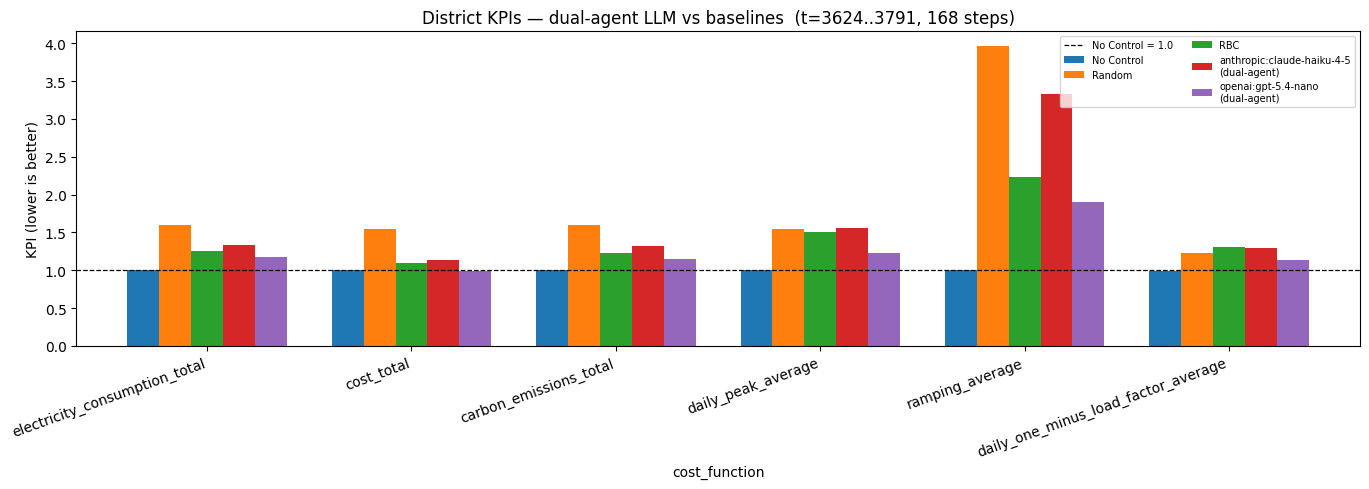

In [ ]:
if present:
    ax = kpi_table.loc[present].plot(kind="bar", figsize=(14, 5), width=0.78)
    ax.axhline(1.0, color="k", ls="--", lw=0.9, label="No Control = 1.0")
    ax.set_ylabel("KPI (lower is better)")
    ax.set_title(
        f"District KPIs — dual-agent LLM vs baselines  "
        f"(t={WEEK_START}..{WEEK_START+WEEK_LEN-1}, {WEEK_LEN} steps)"
    )
    ax.legend(loc="upper right", fontsize=7, ncol=2)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

## § 15 — Per-Agent Breakdown (α vs β)

How much of the district reward does each agent contribute?  
Significant α/β imbalance means one sub-district is being poorly controlled.

In [ ]:
def per_agent_summary(
    df: pd.DataFrame,
    agent_name: str,
    bldg_indices: list[int],
) -> dict:
    """Compute per-agent metrics from the full 6-building rollout dataframe."""
    net_cols = [f"net{i}" for i in bldg_indices]
    r_cols   = [f"r{i}"   for i in bldg_indices]
    soc_cols = [f"soc{i}" for i in bldg_indices]
    a_cols   = [f"a{i}"   for i in bldg_indices]
    dist_net = df[net_cols].sum(axis=1)
    return {
        "agent":             agent_name,
        "buildings":         str(bldg_indices),
        "total_reward":      float(df[r_cols].sum().sum()),
        "mean_soc_pct":      float(df[soc_cols].mean().mean() * 100),
        "peak_net_kW":       float(dist_net.max()),
        "total_net_kWh":     float(dist_net.sum()),
        "mean_action":       float(df[a_cols].values.mean()),
        "std_action":        float(df[a_cols].values.std()),
    }


if llm_runs:
    agent_rows = []
    for name, run in llm_runs.items():
        agent_rows.append(per_agent_summary(run["df"], f"{name} / α", AGENT_A_BUILDINGS))
        agent_rows.append(per_agent_summary(run["df"], f"{name} / β", AGENT_B_BUILDINGS))
    agent_df = pd.DataFrame(agent_rows).set_index("agent")
    print("Per-agent breakdown — α (B0-2) vs β (B3-5)")
    display(agent_df.round(4))
else:
    print("No LLM runs in llm_runs yet — run provider cells above.")

Per-agent breakdown — α (B0-2) vs β (B3-5)


,buildings,total_reward,mean_soc_pct,peak_net_kW,total_net_kWh,mean_action,std_action
agent,,,,,,,
anthropic / α,"[0, 1, 2]",-1084.7855,69.4151,13.7074,504.3722,0.0347,0.2786
anthropic / β,"[3, 4, 5]",-1527.9144,66.5967,21.2247,839.7733,0.0403,0.3012
openai / α,"[0, 1, 2]",-916.0256,64.1737,13.7074,481.5072,0.0140,0.1743
openai / β,"[3, 4, 5]",-1303.5184,65.1076,12.0350,803.1932,0.0088,0.1812


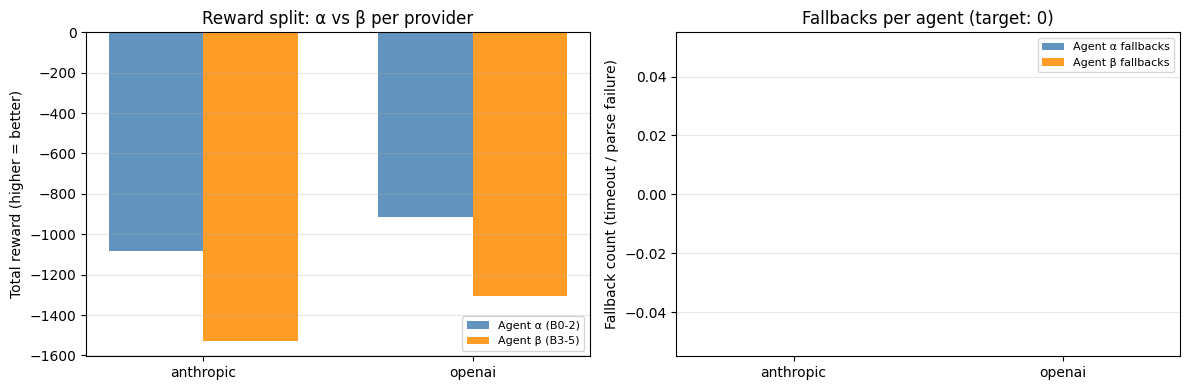

In [ ]:
if llm_runs:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    providers  = list(llm_runs.keys())
    reward_a   = [llm_runs[n]["df"]["reward_a"].sum() for n in providers]
    reward_b   = [llm_runs[n]["df"]["reward_b"].sum() for n in providers]
    x          = range(len(providers))

    # Panel 1 — reward split α vs β
    w = 0.35
    axes[0].bar([i - w/2 for i in x], reward_a, width=w, label="Agent α (B0-2)", alpha=0.85, color="steelblue")
    axes[0].bar([i + w/2 for i in x], reward_b, width=w, label="Agent β (B3-5)", alpha=0.85, color="darkorange")
    axes[0].set_xticks(list(x)); axes[0].set_xticklabels(providers)
    axes[0].set_ylabel("Total reward (higher = better)")
    axes[0].set_title("Reward split: α vs β per provider")
    axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3, axis="y")

    # Panel 2 — fallback counts
    fb_a = [sum(1 for r in llm_runs[n]["raw_log_a"] if r["fallback"]) for n in providers]
    fb_b = [sum(1 for r in llm_runs[n]["raw_log_b"] if r["fallback"]) for n in providers]
    axes[1].bar([i - w/2 for i in x], fb_a, width=w, label="Agent α fallbacks", alpha=0.85, color="steelblue")
    axes[1].bar([i + w/2 for i in x], fb_b, width=w, label="Agent β fallbacks", alpha=0.85, color="darkorange")
    axes[1].set_xticks(list(x)); axes[1].set_xticklabels(providers)
    axes[1].set_ylabel("Fallback count (timeout / parse failure)")
    axes[1].set_title("Fallbacks per agent (target: 0)")
    axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3, axis="y")

    plt.tight_layout()
    plt.show()

## § 16 — Diagnostics

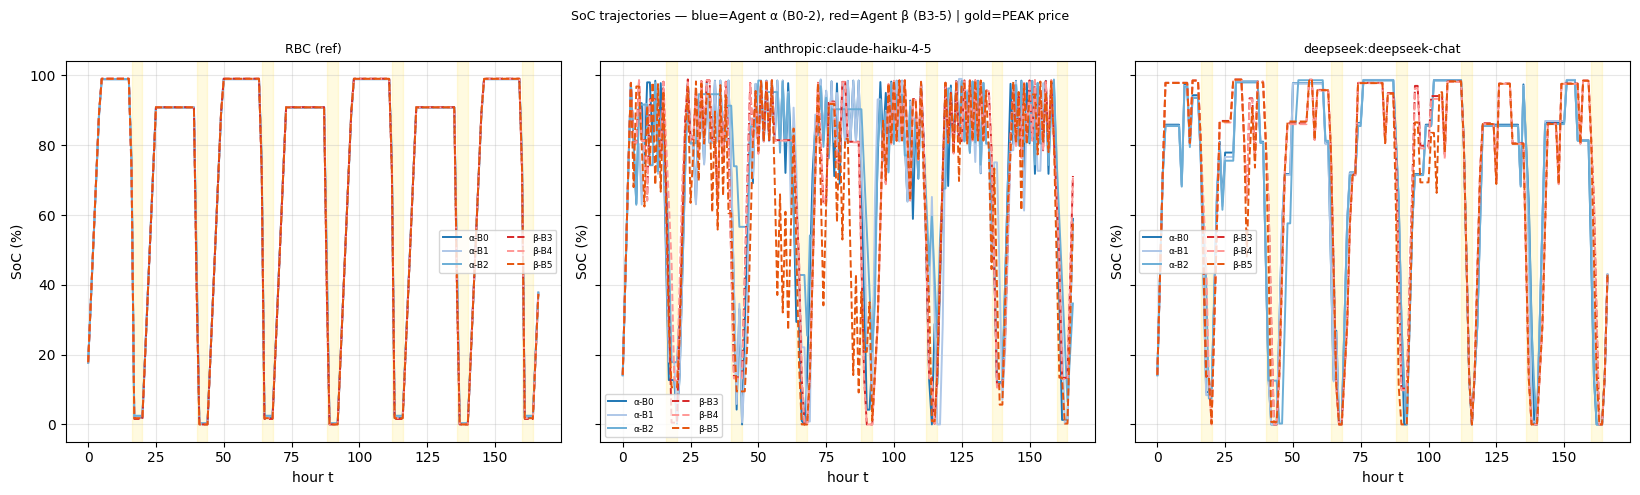

In [ ]:
# 15.1  SoC trajectories — coloured by agent group, one column per provider
if not llm_runs:
    print("No LLM runs yet.")
else:
    panels = [(df_rbc, "RBC (ref)")] + [(run["df"], run["label"]) for run in llm_runs.values()]
    fig, axes = plt.subplots(1, len(panels), figsize=(5.5 * len(panels), 5), sharey=True)
    if len(panels) == 1:
        axes = [axes]

    colors_a = ["#1f77b4", "#aec7e8", "#6baed6"]   # blues for α
    colors_b = ["#d62728", "#ff9896", "#e6550d"]   # reds  for β

    for ax, (df_, label) in zip(axes, panels):
        for local_i, global_i in enumerate(AGENT_A_BUILDINGS):
            ax.plot(df_["t"], df_[f"soc{global_i}"] * 100,
                    label=f"α-B{global_i}", lw=1.4, color=colors_a[local_i])
        for local_i, global_i in enumerate(AGENT_B_BUILDINGS):
            ax.plot(df_["t"], df_[f"soc{global_i}"] * 100,
                    label=f"β-B{global_i}", lw=1.4, color=colors_b[local_i], ls="--")

        # Shade PEAK price hours
        peak_mask = (df_["price"] >= PRICE_PEAK_THRESHOLD).values
        in_peak, span_s = False, 0
        for i_m, is_peak in enumerate(peak_mask):
            if is_peak and not in_peak:
                span_s = i_m; in_peak = True
            elif not is_peak and in_peak:
                ax.axvspan(span_s, i_m - 1, color="gold", alpha=0.12); in_peak = False
        if in_peak:
            ax.axvspan(span_s, len(peak_mask) - 1, color="gold", alpha=0.12)

        ax.set_xlabel("hour t"); ax.set_ylabel("SoC (%)")
        ax.set_title(label, fontsize=9)
        ax.legend(ncol=2, fontsize=6.5); ax.grid(alpha=0.3)

    plt.suptitle("SoC trajectories — blue=Agent α (B0-2), red=Agent β (B3-5) | gold=PEAK price", fontsize=9)
    plt.tight_layout()
    plt.show()

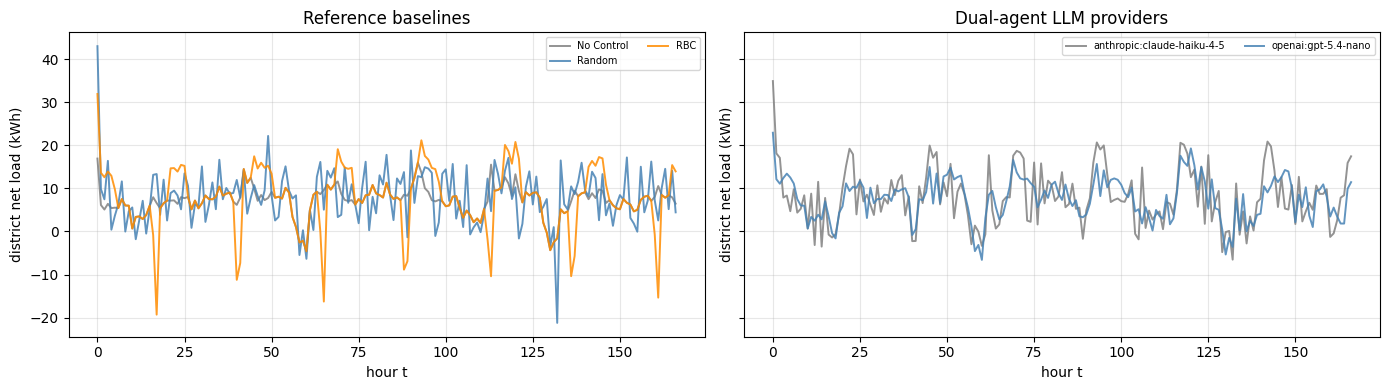

In [ ]:
# 15.2  District net load comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

def _plot_net(ax, dfs_labels, title):
    colors = ["gray", "steelblue", "darkorange", "crimson", "forestgreen", "purple"]
    for (df_, lbl), color in zip(dfs_labels, colors):
        net = df_[[f"net{i}" for i in range(6)]].sum(axis=1)
        ax.plot(df_["t"], net, label=lbl, lw=1.4, color=color, alpha=0.85)
    ax.set_xlabel("hour t"); ax.set_ylabel("district net load (kWh)")
    ax.set_title(title); ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3)

ref_panels = [(df_noop, "No Control"), (df_random, "Random"), (df_rbc, "RBC")]
_plot_net(axes[0], ref_panels, "Reference baselines")

llm_panels = [(run["df"], run["label"]) for run in llm_runs.values()]
if llm_panels:
    _plot_net(axes[1], llm_panels, "Dual-agent LLM providers")
else:
    axes[1].text(0.5, 0.5, "No LLM runs yet", ha="center", va="center", transform=axes[1].transAxes)

plt.tight_layout()
plt.show()

In [ ]:
# 15.3  Behavioural summary per provider (synchronisation, rule violations)
def analyze_dual_run(run: dict) -> list[dict]:
    rows = []
    df   = run["df"]
    for agent_lbl, bldg_ids, raw_log in [
        ("α", AGENT_A_BUILDINGS, run["raw_log_a"]),
        ("β", AGENT_B_BUILDINGS, run["raw_log_b"]),
    ]:
        a_cols   = [f"a{i}" for i in bldg_ids]
        soc_cols = [f"soc{i}" for i in bldg_ids]
        A        = df[a_cols].values
        signs    = np.sign(A)
        sync     = float(np.all(signs == signs[:, [0]], axis=1).mean())
        fb       = float(np.mean([r["fallback"] for r in raw_log])) if raw_log else 0.0
        SOC_post = df[soc_cols].values
        SOC_pre  = np.vstack([np.zeros(len(bldg_ids)), SOC_post[:-1]])
        rows.append({
            "provider":          run["label"],
            "agent":             agent_lbl,
            "sync_rate_pct":     round(sync * 100, 1),
            "fallback_pct":      round(fb * 100, 1),
            "charge_at_full":    int(((A > 0) & (SOC_pre >= 0.9)).sum()),
            "discharge_at_empty": int(((A < 0) & (SOC_pre <= 0.1)).sum()),
            "mean_action":       round(float(A.mean()), 3),
            "std_action":        round(float(A.std()), 3),
        })
    return rows


if llm_runs:
    beh_rows = []
    for run in llm_runs.values():
        beh_rows.extend(analyze_dual_run(run))
    beh_df = pd.DataFrame(beh_rows)
    print("Behavioural summary:")
    display(beh_df.set_index(["provider", "agent"]).round(3))
    print(
        "\nLow sync_rate is GOOD (agents act independently → lower demand spikes).\n"
        "fallback_pct = timeout + parse failures (target: 0).\n"
        "charge_at_full / discharge_at_empty = prompt-rule violations."
    )

Behavioural summary:


sync_rate_pct  fallback_pct  charge_at_full  \
provider                   agent                                                
anthropic:claude-haiku-4-5 α               53.9           0.0               0   
                           β               56.9           0.0               0   
openai:gpt-5.4-nano        α               49.7           0.0               4   
                           β               46.7           0.0               4   

                                  discharge_at_empty  mean_action  std_action  
provider                   agent                                               
anthropic:claude-haiku-4-5 α                       1        0.035       0.279  
                           β                       0        0.040       0.301  
openai:gpt-5.4-nano        α                       3        0.014       0.174  
                           β                       6        0.009       0.181


Low sync_rate is GOOD (agents act independently → lower demand spikes).
fallback_pct = timeout + parse failures (target: 0).
charge_at_full / discharge_at_empty = prompt-rule violations.


In [ ]:
# 15.4  Sample raw responses — 1 timestep per provider, both agents side by side
N_SHOW = 1

if not llm_runs:
    print("No LLM runs yet.")
else:
    rng_diag = np.random.default_rng(SEED)
    ref_log  = next(iter(llm_runs.values()))["raw_log_a"]
    picked   = sorted(rng_diag.choice(len(ref_log), size=min(N_SHOW, len(ref_log)), replace=False).tolist())

    for idx in picked:
        t_val = ref_log[idx]["t"]
        print("═" * 72)
        print(f"t={t_val}")
        for name, run in llm_runs.items():
            entry_a = run["raw_log_a"][idx]
            entry_b = run["raw_log_b"][idx]
            print(f"\n── {run['label']} ──")
            print(f"  Agent α state:\n{entry_a['state_text']}")
            print(f"  Agent α response (fallback={entry_a['fallback']}):\n{entry_a['raw']}")
            print(f"  Agent β state:\n{entry_b['state_text']}")
            print(f"  Agent β response (fallback={entry_b['fallback']}):\n{entry_b['raw']}")
        print()

════════════════════════════════════════════════════════════════════════
t=14

── anthropic:claude-haiku-4-5 ──
  Agent α state:
Month 12, Fri 13:00  |  price=0.210 (LOW)  |  carbon=0.207 (MID)
Forecast:  price+6h=PEAK  price+12h=LOW  solar+6h=NONE
Buildings:
  B0: SoC= 98.5%  load=3.43 kWh  last_net=+1.76 kWh  solar=HIGH
  B1: SoC= 98.5%  load=0.78 kWh  last_net=+2.24 kWh  solar=HIGH
  B2: SoC= 98.4%  load=0.31 kWh  last_net=+1.58 kWh  solar=HIGH
  Agent α response (fallback=False):
<thought>
All buildings at ~98% SoC with HIGH solar. Price LOW now, PEAK in 6h. Cannot charge (SoC >90%). Discharge to reduce grid pull and prepare for peak pricing ahead.
</thought>

<action building=0>DISCHARGE_40</action>
<action building=1>DISCHARGE_20</action>
<action building=2>DISCHARGE_20</action>
  Agent β state:
Month 12, Fri 13:00  |  price=0.210 (LOW)  |  carbon=0.207 (MID)
Forecast:  price+6h=PEAK  price+12h=LOW  solar+6h=NONE
Buildings:
  B0: SoC= 98.2%  load=0.59 kWh  last_net=+1.84 kWh  sol

## § 17 — Save Artifacts

In [ ]:
stamp = time.strftime("%Y%m%d_%H%M%S")

# ── Rollout CSVs ──────────────────────────────────────────────────────────
all_dfs = [df_noop, df_random, df_rbc] + [run["df"] for run in llm_runs.values()]
df_all  = pd.concat(all_dfs, ignore_index=True)
csv_path = ARTIFACTS / f"02_rollouts_{stamp}.csv"
df_all.to_csv(csv_path, index=False)
print(f"Rollout data    : {csv_path}")

# ── KPI table ─────────────────────────────────────────────────────────────
if present:
    kpi_path = ARTIFACTS / f"02_kpis_{stamp}.csv"
    kpi_table.loc[present].to_csv(kpi_path)
    print(f"KPI table       : {kpi_path}")

# ── Per-agent summary ─────────────────────────────────────────────────────
if llm_runs:
    agent_path = ARTIFACTS / f"02_per_agent_{stamp}.csv"
    agent_df.to_csv(agent_path)
    print(f"Per-agent table : {agent_path}")

# ── Raw LLM logs (JSON) ───────────────────────────────────────────────────
for name, run in llm_runs.items():
    for agent_key in ("raw_log_a", "raw_log_b"):
        tag      = "alpha" if agent_key == "raw_log_a" else "beta"
        log_path = ARTIFACTS / f"02_raw_{name}_{tag}_{stamp}.json"
        with open(log_path, "w") as f:
            json.dump(run[agent_key], f, indent=2)
        print(f"Raw log {name}/{tag:5s}: {log_path}")